Code to plot streamlines of the flow where the velocities are relative to the ring, and therefore should show some stagnation point.

In [137]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm
import scipy.signal as signal

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()
print(plt.rcParams["figure.dpi"])


h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
# h5file = h5py.File('E:/H5/WideFOV.h5', 'r')

vels = h5file['Narrow']['U100']['L100']['RPM3']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
# u, v = u/0.1, v/0.1 
r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[1], u.shape[2])
Time = oj.frames_to_seconds(u, v, 90)
h5file.close()

VortLocMax, VortLocMin = oj.vorticityPeakTracking_inter(u[:,:,:], v[:,:,:]) # Axis 0 is radial, axis 1 is axial
#normalise location about the axis of rotation
VortLocMin[:,0] = np.subtract(VortLocMin[:,0], int(u.shape[1]/2))
VortLocMax[:,0] = np.subtract(VortLocMax[:,0], int(u.shape[1]/2))

C:/Coding
Thesis plot settings applied
400.0


find ring speed:
* first try I will take an average then maybe i need to do a derivative.
* to start with I will do no scaling to see if it works

0.06545455893090672


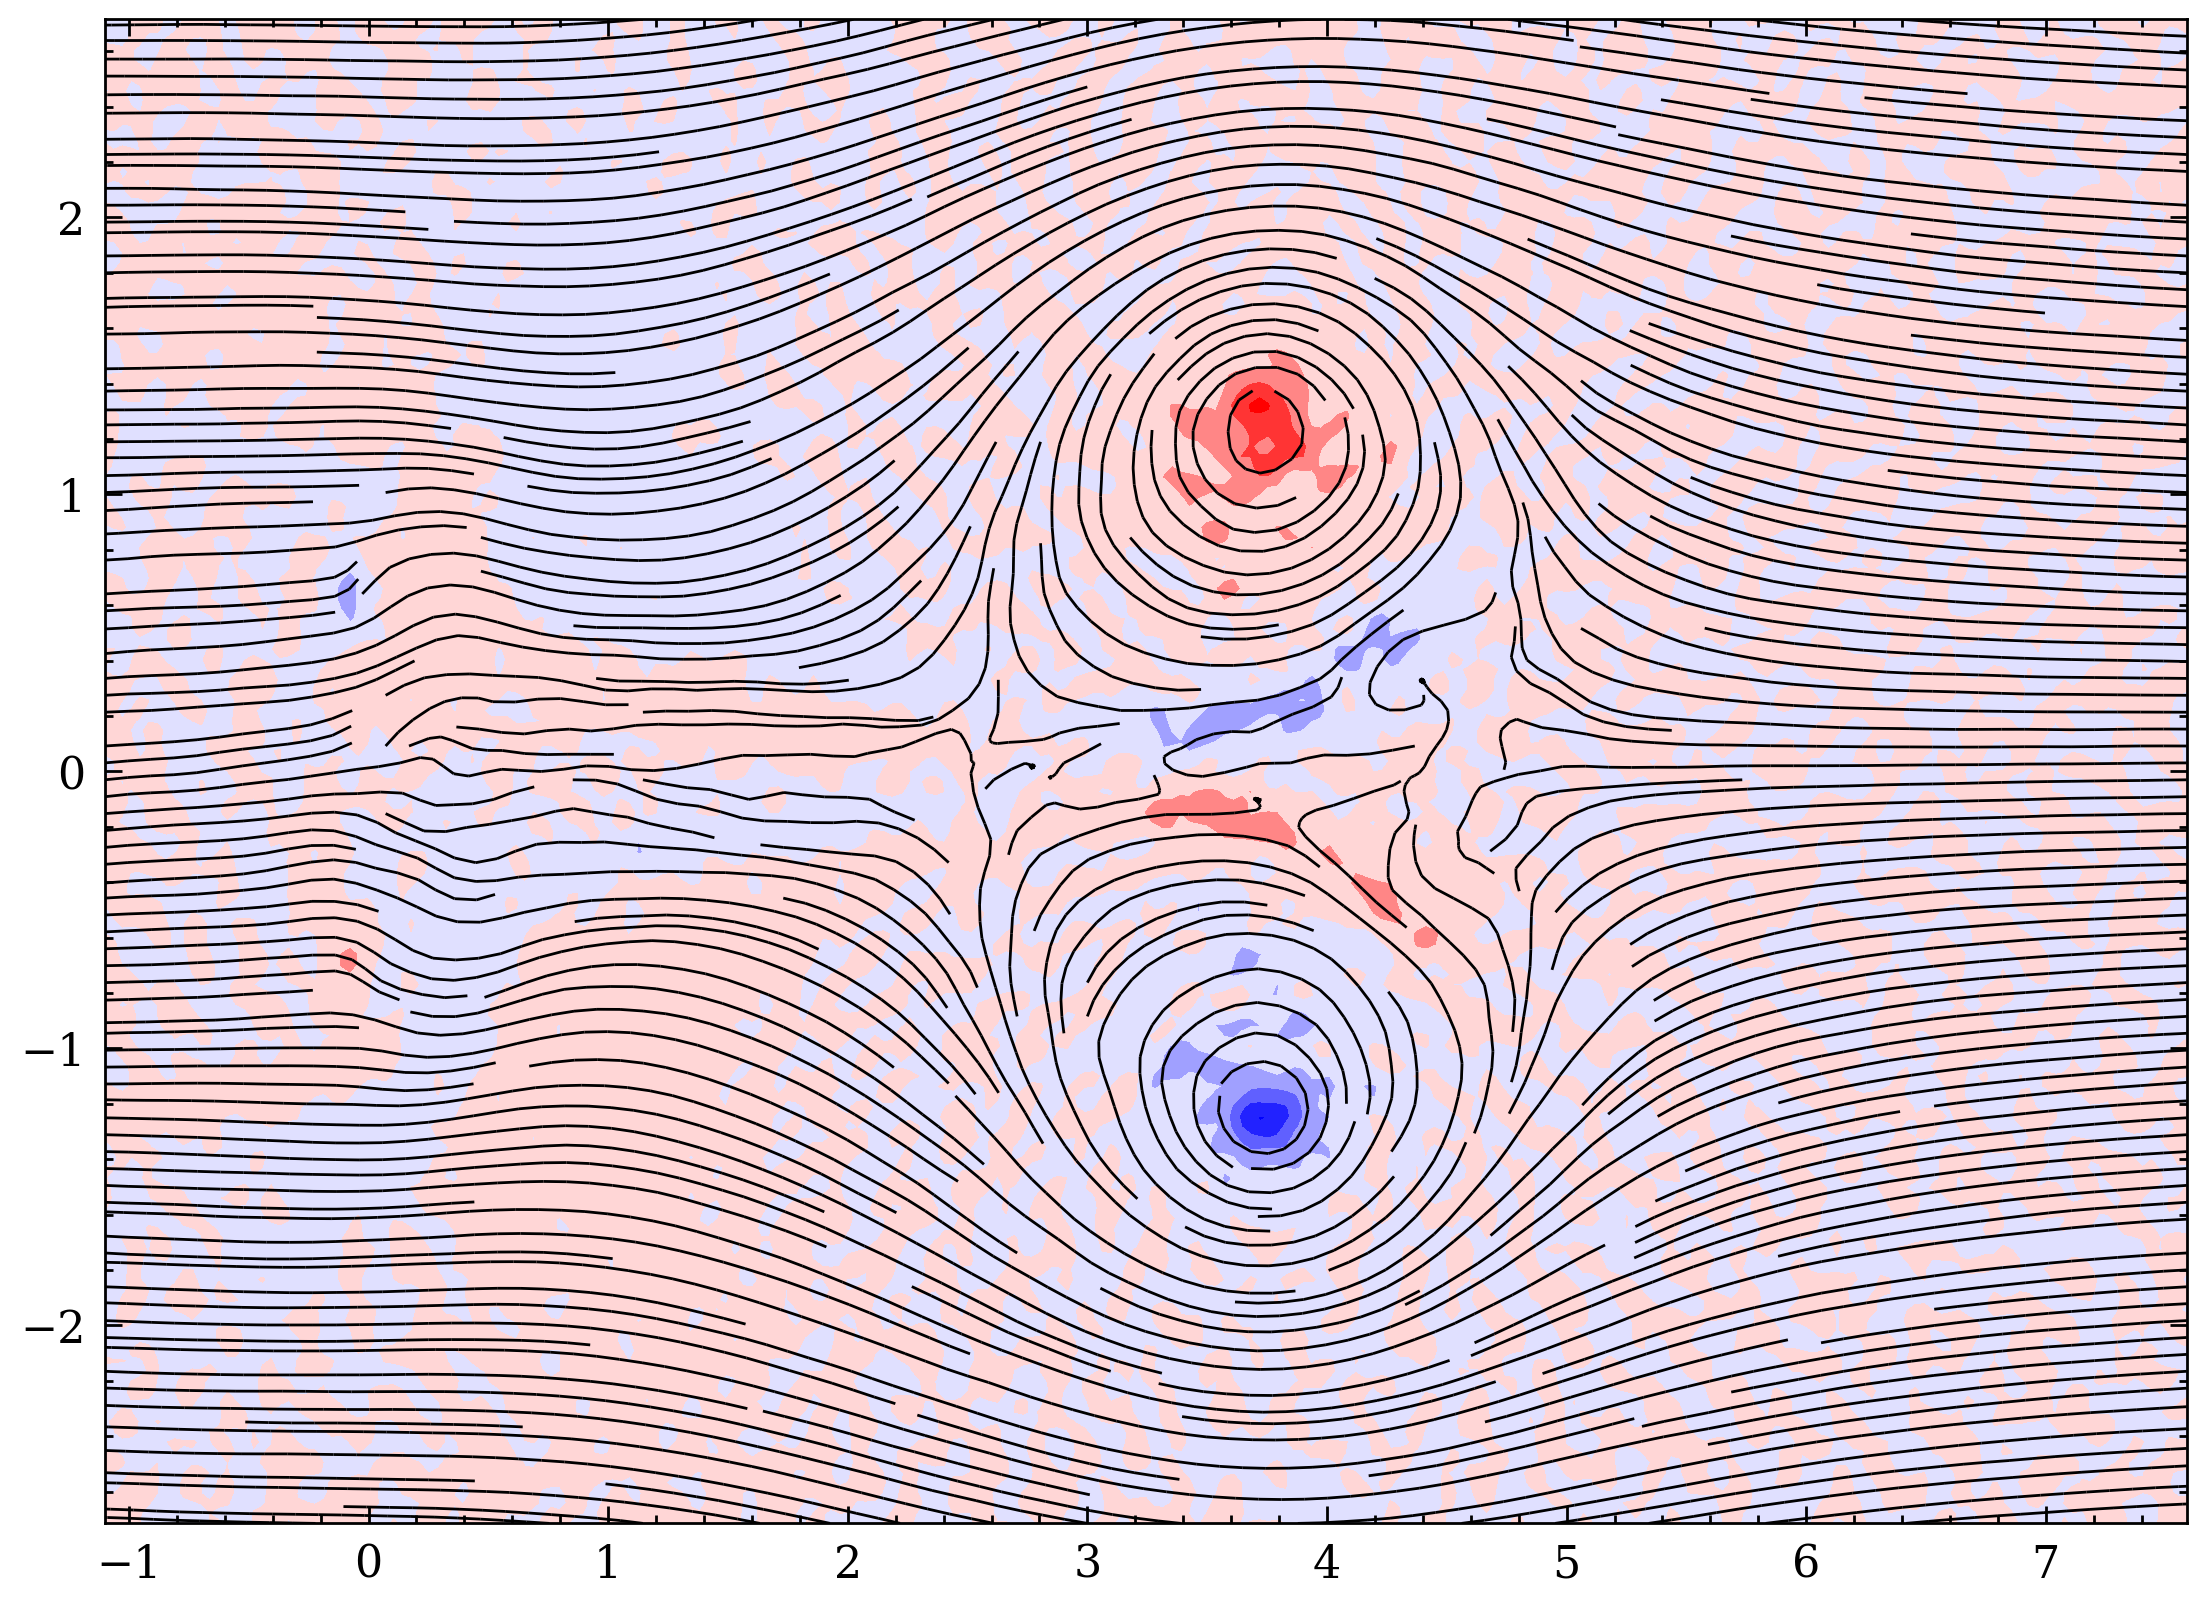

In [140]:
start_frame = 71
r0 = 31
frame = 350

n_pixels = 1920
n_points = 239
factor = n_pixels/n_points

u_ring = (np.max(VortLocMax[:,1])-r0)/(np.argmax(VortLocMax[:,1])-start_frame)
# u_ring = np.mean()
vort, vort_gauss = oj.calculate_vorticity(u, v)
norm = colors.TwoSlopeNorm(vmin=np.min(vort[frame,:,:]), vcenter=0, vmax=np.max(vort[frame,:,:]))
u_rel = u[frame,:,:] - u_ring/factor
# u_rel = u[frame,:,:] - 0.06058233103357348
# u_rel = u[frame,:,:] - 0.037/2
# u_rel = u[frame,:,:] - 0.01

f1, ax = plt.subplots(1, 1,)
ax.contourf(z_nd, r_nd, vort[frame,:,:], cmap = 'bwr',norm = norm)
ax.streamplot(z_nd, r_nd, u_rel, v[frame,:,:], density=3, color='k', linewidth=0.5, arrowsize=0)
# ax[1].quiver(z_nd, r_nd, u[frame,:,:], v[frame,:,:])
# ax[1].contourf(z_nd, r_nd, u[frame,:,:], cmap = 'bwr', norm = norm)

print(np.max(u[350,:,:]))

gradient finding method:
* fit a spline to the data
* take the gradient of the data
* subtract the gradient from the ring

0.3935950814615147


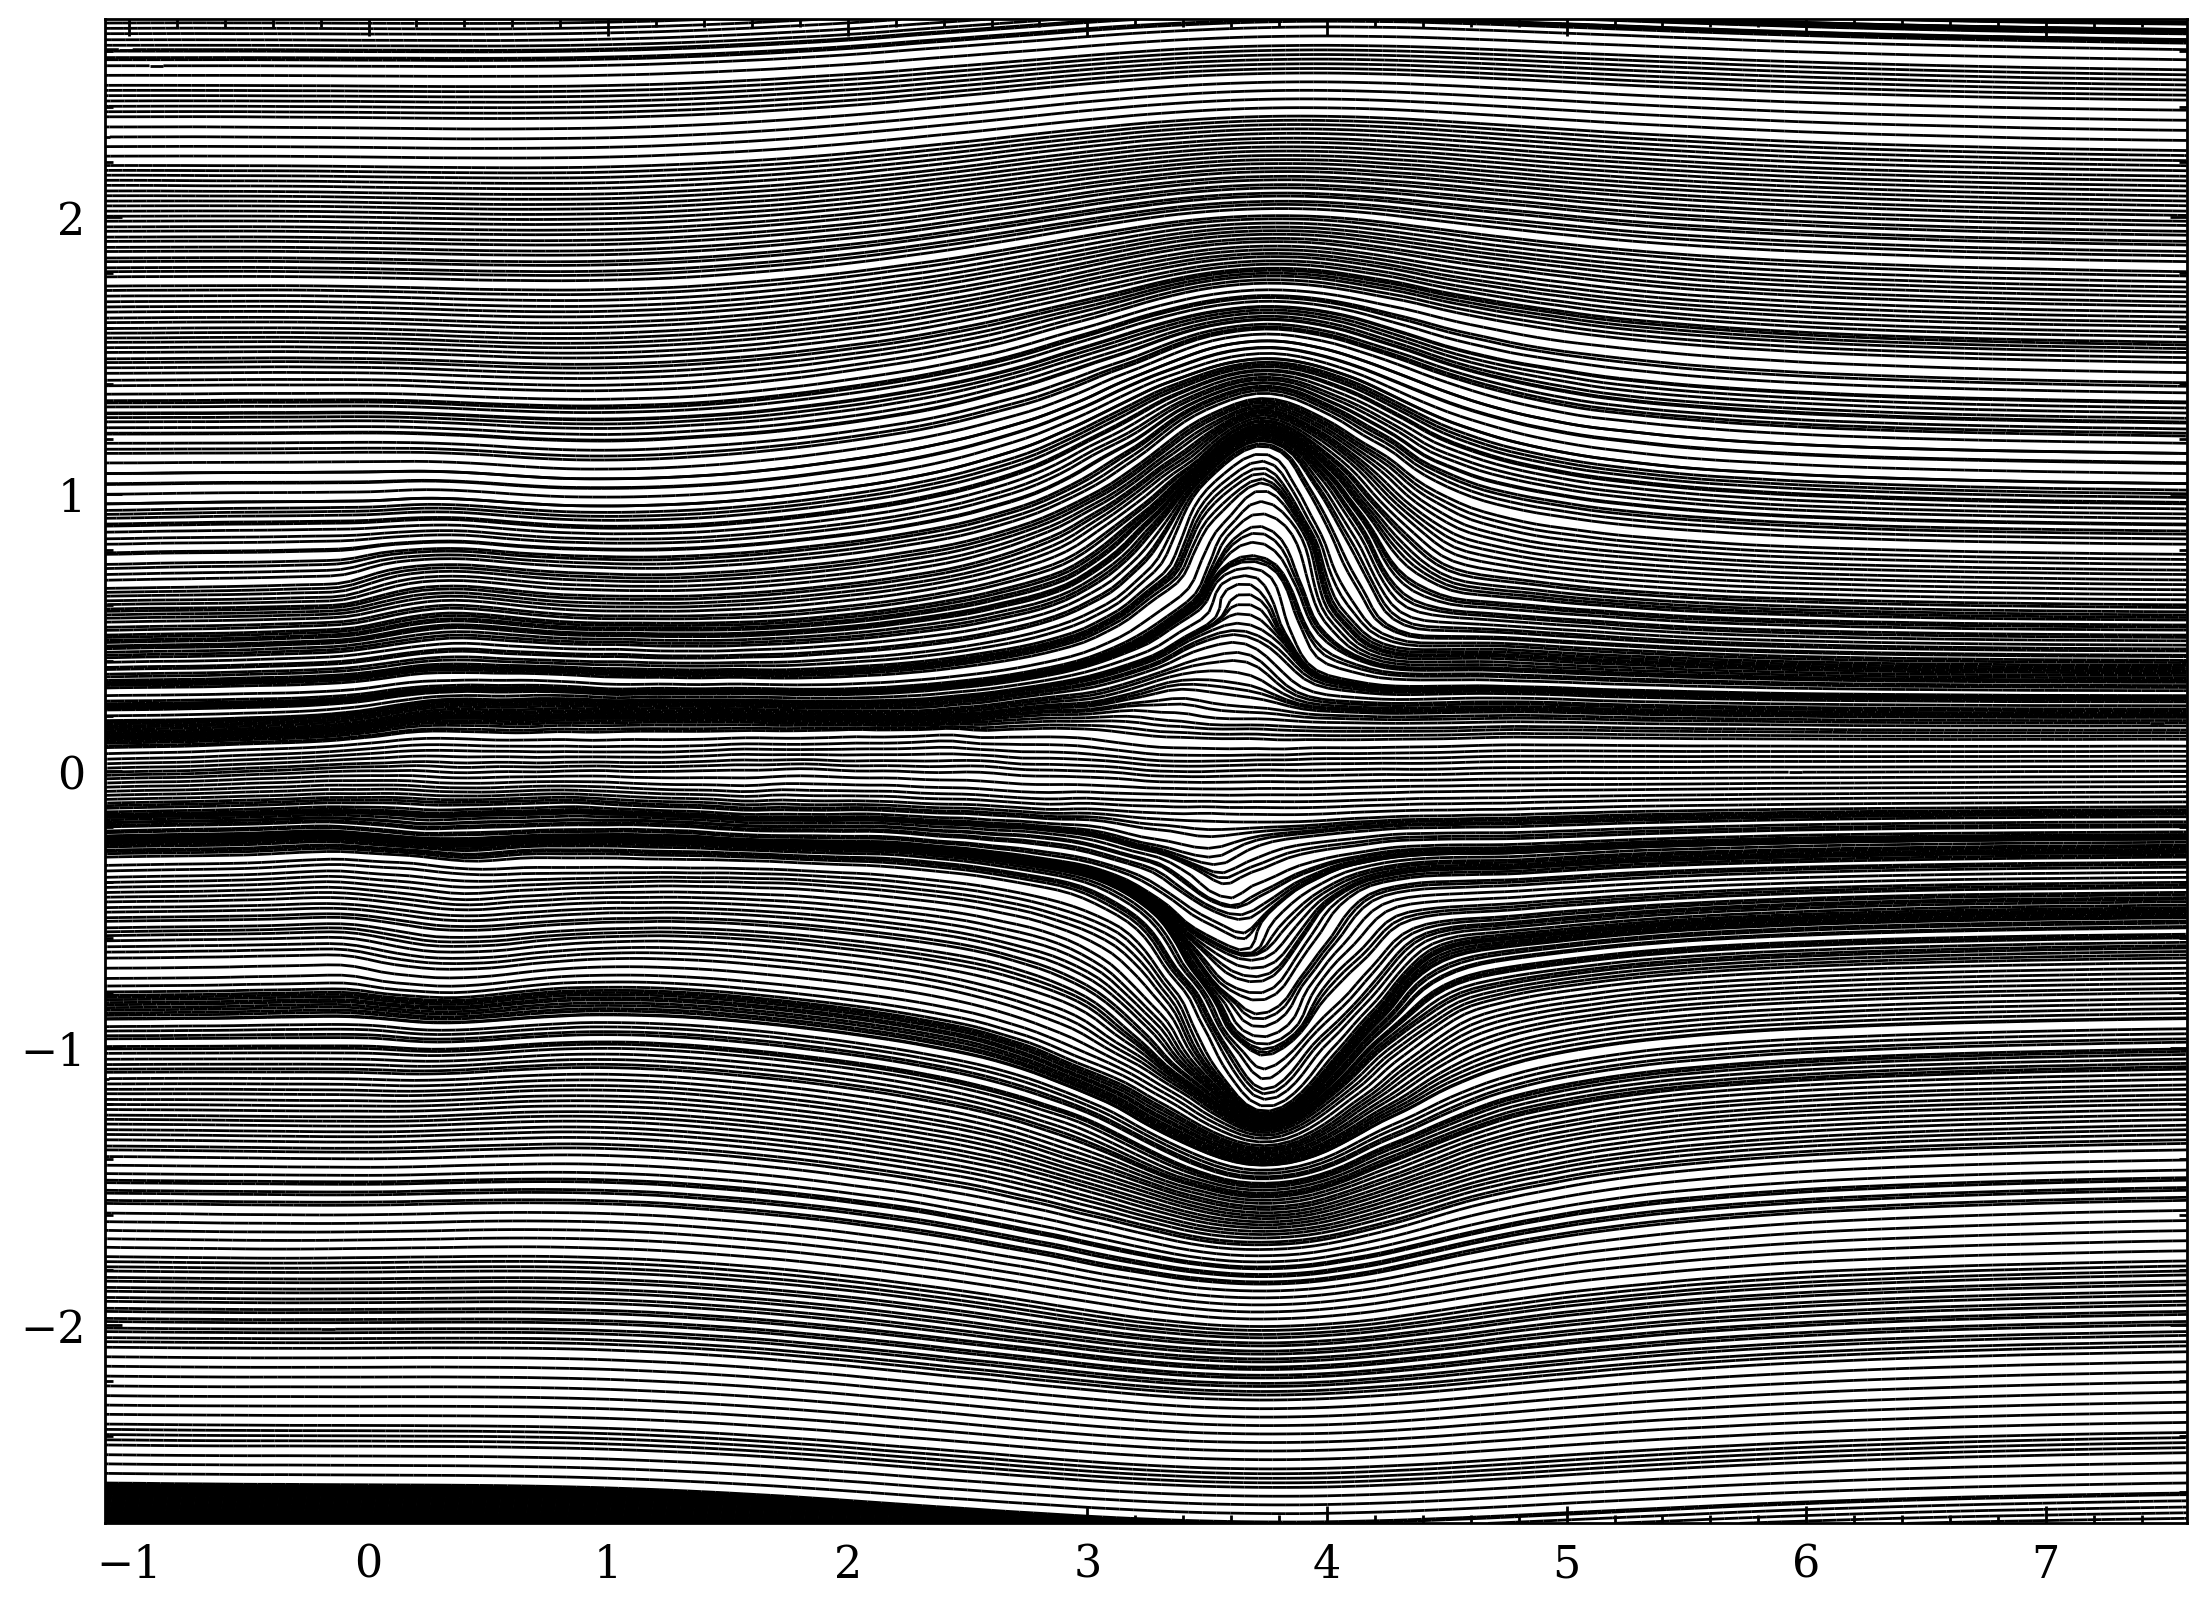

In [139]:
from scipy.interpolate import CubicSpline
from scipy.signal import savgol_filter

n_pixels = 1920
n_points = 239
factor = n_pixels/n_points

vort_spline = np.interp(Time, Time, VortLocMax[:,1])
savgol = savgol_filter(vort_spline, 50, 2, deriv = 0)
savgol_grad = savgol_filter(vort_spline, 50, 2, deriv = 1)
grad = np.gradient(vort_spline)

# fig, ax = plt.subplots(1, 1)
# # ax.plot(vort_spline)
# # ax.plot(savgol)
# ax.plot(savgol_grad, label = 'Savgol')
# # ax.plot(Time, grad, label = 'Gradient')
# # ax.set_xlim(0, 2.5)
# ax.set_xlim(100, 450)
# # ax.set_ylim(-2.7148, 2.7148)
# plt.legend()

print(np.mean(savgol_grad[100:450]))
frame = 350

f2, ax2 = plt.subplots(1, 1)
ax2.streamplot(z_nd, r_nd, u[frame,:,:]-grad[frame]/factor, v[frame,:,:], density=5, color='k', linewidth=0.5, arrowsize=0, broken_streamlines=False)